# 1️⃣ ربط جوجل درايف

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/'))

['Balqees AL-Zaidanin.cv.pdf', 'Colab Notebooks', 'derma_model.h5', 'derma_model_v2.h5', 'تسجيل في follow up - Spain.gform', 'Dataset.zip', 'Rescued document (1).docx', 'pending_review', 'motion_photo_472146235325202002 (1).jpg', 'IMG-20260426-WA0005 (1).jpg', 'IMG-20260426-WA0006 (1).jpg', 'motion_photo_472146235325202002.jpg', 'IMG-20260426-WA0005.jpg', 'IMG-20260426-WA0006.jpg', 'IMG-20260426-WA0003 (1).jpg', 'IMG-20260426-WA0003.jpg', 'واجب .pdf', 'واجبات.pdf', 'class_names.json', 'derma_model_v2.keras', 'training_curves.png', 'confusion_matrix.png']


# 2️⃣ تعريف المسارات والإعدادات

In [ ]:
IMG_SIZE = (224, 224)
MAX_PER_CLASS = 500
ZIP_PATH = "/content/drive/MyDrive/Dataset.zip"
EXTRACT_DIR = "/content/extracted"
OUTPUT_DIR = "/content/resized_data"

# 3️⃣ فك ضغط الملف

In [ ]:
print("جاري الاستخراج...")
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
print("تم فك الضغط!")

جاري الاستخراج...
تم فك الضغط!


In [ ]:
import os

for root, dirs, files in os.walk('/content'):
    for file in files:
        if file.endswith('.csv'):
            print(os.path.join(root, file))

/content/extracted/Dataset/archive (4)/product_info.csv
/content/extracted/Dataset/archive (4)/product_info_skincare.csv
/content/extracted/Dataset/archive (4)/reviews_750-1250_masked.csv
/content/extracted/Dataset/archive (4)/reviews_250-500_masked.csv
/content/extracted/Dataset/archive (4)/reviews_1250-end_masked.csv
/content/extracted/Dataset/archive (4)/reviews_500-750_masked.csv
/content/extracted/Dataset/archive (4)/reviews_0-250_masked.csv
/content/extracted/Dataset/archive (3)/Ulta Skincare Reviews.csv
/content/extracted/Dataset/archive (5)/CELESTIA SKIN CARE DASTASET.csv
/content/extracted/Dataset/archive (7)/fitzpatrick17k-main/fitzpatrick17k-main/fitzpatrick17k.csv
/content/extracted/Dataset/archive (7)/fitzpatrick17k-main/fitzpatrick17k-main/annotation_evaluation/data/x_df.csv
/content/extracted/Dataset/archive (7)/fitzpatrick17k-main/fitzpatrick17k-main/annotation_evaluation/data/x_heatmap_df.csv
/content/extracted/Dataset/archive (7)/fitzpatrick17k-main/fitzpatrick17k-mai

In [ ]:
import pandas as pd
import os

# البحث عن كل ملفات CSV
csv_files = []

for root, dirs, files in os.walk('/content/extracted'):
    for file in files:
        if file.endswith('.csv'):
            csv_files.append(os.path.join(root, file))

# عرض البيانات
for file in csv_files:
    print("="*80)
    print("اسم الملف:", file)
    print("="*80)

    try:
        df = pd.read_csv(file)
        print(df.head())
    except Exception as e:
        print("خطأ في قراءة الملف:", e)

    print("\n")

اسم الملف: /content/extracted/Dataset/archive (4)/product_info.csv
  product_id               product_name  brand_id brand_name  loves_count  \
0    P473671    Fragrance Discovery Set      6342      19-69         6320   
1    P473668    La Habana Eau de Parfum      6342      19-69         3827   
2    P473662  Rainbow Bar Eau de Parfum      6342      19-69         3253   
3    P473660       Kasbah Eau de Parfum      6342      19-69         3018   
4    P473658  Purple Haze Eau de Parfum      6342      19-69         2691   

   rating  reviews            size                      variation_type  \
0  3.6364     11.0             NaN                                 NaN   
1  4.1538     13.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   
2  4.2500     16.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   
3  4.4762     21.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   
4  3.2308     13.0  3.4 oz/ 100 mL  Size + Concentration + Formulation   

  variation_value  ... on

/tmp/ipykernel_19897/350427977.py:19: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file)


   Unnamed: 0                                hasher  \
0           0  df71e3f044c167de37cf68692e3316ff.jpg   
1           1  f8156f640422d608c266be1fc691169c.jpg   
2           3  9dc3ea5d2c25d1c0389dfd605ce1ef94.jpg   
3           4  2b71ada28a05084783c7514c01f2e9e9.jpg   
4           5  10822b10a81c49283f6abf87264f9464.jpg   

                                              source  e_label  ra_label  \
0  Book - Taylor and Kellys Dermatology for Skin ...        5         5   
1        Book - Fitzpatricks Dermatology (Kang 2019)        3         1   
2                 Book - Dermatology (Bolognia 2018)        5         5   
3                 Book - Dermatology (Bolognia 2018)        2         1   
4           Book - Clinical dermatology (Habif 2010)        2         2   

   e2_label  e3_label  
0         6         6  
1         2         1  
2         5         5  
3         2         2  
4         3         2  


اسم الملف: /content/extracted/Dataset/archive (7)/fitzpatrick17k-main/fi

# 4️⃣ تحديد فولدر الداتا الرئيسي (أول فولدر فيه مجلدات فرعية)

In [ ]:
DATA_DIR = EXTRACT_DIR
for root, dirs, files in os.walk(EXTRACT_DIR):
    subfolders = [d for d in dirs if os.path.isdir(os.path.join(root, d))]
    if len(subfolders) >= 2:
        DATA_DIR = root
        break

print(f"فولدر الداتا: {DATA_DIR}")
print("الفئات الموجودة:")
for cls in os.listdir(DATA_DIR):
    cls_path = os.path.join(DATA_DIR, cls)
    if os.path.isdir(cls_path):
        print(f"  {cls}: {len(os.listdir(cls_path))} صورة")

فولدر الداتا: /content/extracted/Dataset
الفئات الموجودة:
  archive (5): 1 صورة
  archive (6): 1 صورة
  archive (1): 1 صورة
  archive: 1 صورة
  archive (4): 7 صورة
  archive (7): 5 صورة
  archive (3): 1 صورة
  archive(2): 1 صورة


# 5️⃣ تصغير الصور وحفظها في OUTPUT_DIR

In [ ]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_images = []
for root, dirs, files in os.walk(DATA_DIR):
    image_files = [f for f in files if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if image_files:
        cls_name = os.path.basename(root)
        cls_out = os.path.join(OUTPUT_DIR, cls_name)
        os.makedirs(cls_out, exist_ok=True)

        for i, img_name in enumerate(image_files[:MAX_PER_CLASS]):
            try:
                img = Image.open(os.path.join(root, img_name)).convert('RGB')
                img = img.resize(IMG_SIZE, Image.LANCZOS)
                img.save(os.path.join(cls_out, f'{cls_name}_{i}.jpg'), 'JPEG', quality=85)
            except:
                pass

        print(f"{cls_name}: تم تصغير {len(image_files[:MAX_PER_CLASS])} صور")
        all_images.extend([os.path.join(cls_out, f'{cls_name}_{i}.jpg') for i in range(len(image_files[:MAX_PER_CLASS]))])

print(f"\nانتهى! تم معالجة {len(all_images)} صورة. الداتا الجديدة في: {OUTPUT_DIR}")

normal: تم تصغير 111 صور
oily: تم تصغير 80 صور
dry: تم تصغير 71 صور
normal: تم تصغير 59 صور
oily: تم تصغير 40 صور
dry: تم تصغير 35 صور
normal: تم تصغير 500 صور
oily: تم تصغير 500 صور
dry: تم تصغير 500 صور
blackheades: تم تصغير 500 صور
dark spots: تم تصغير 500 صور
wrinkles: تم تصغير 500 صور
pores: تم تصغير 500 صور
acne: تم تصغير 500 صور
dark spots: تم تصغير 303 صور
wrinkles: تم تصغير 300 صور
puffy eyes: تم تصغير 300 صور
4788-images-Human-Facial-Skin-Defects-Data-main: تم تصغير 5 صور
blackheades: تم تصغير 500 صور
dark spots: تم تصغير 500 صور
wrinkles: تم تصغير 500 صور
pores: تم تصغير 500 صور
acne: تم تصغير 500 صور
imgs_part_1: تم تصغير 500 صور
imgs_part_2: تم تصغير 500 صور
imgs_part_3: تم تصغير 500 صور
Level_0: تم تصغير 387 صور
Level_1: تم تصغير 473 صور
Level_2: تم تصغير 139 صور

انتهى! تم معالجة 10303 صورة. الداتا الجديدة في: /content/resized_data


# 6️⃣ حذف الفئات الغلط أو الغير مرغوبة

In [ ]:
for cls in os.listdir(OUTPUT_DIR):
    cls_path = os.path.join(OUTPUT_DIR, cls)
    if not os.path.isdir(cls_path):
        continue
    if ("imgs_part" in cls.lower() or "archive" in cls.lower() or "level" in cls.lower()):
        shutil.rmtree(cls_path)
        print(f"🗑️ تم حذف: {cls}")

🗑️ تم حذف: Level_0
🗑️ تم حذف: imgs_part_1
🗑️ تم حذف: imgs_part_2
🗑️ تم حذف: imgs_part_3
🗑️ تم حذف: Level_1
🗑️ تم حذف: Level_2


# 7️⃣ دمج الفئات المتكررة (مثال: _wrinkles → wrinkles)

In [ ]:
def merge(src, dest):
    if not os.path.exists(src):
        return
    os.makedirs(dest, exist_ok=True)
    for f in os.listdir(src):
        shutil.move(os.path.join(src, f), os.path.join(dest, f))
    os.rmdir(src)
    print(f"✅ دمج {src} → {dest}")

merge(os.path.join(OUTPUT_DIR, "_wrinkles"), os.path.join(OUTPUT_DIR, "wrinkles"))
merge(os.path.join(OUTPUT_DIR, "_dark spots"), os.path.join(OUTPUT_DIR, "dark spots"))
merge(os.path.join(OUTPUT_DIR, "_puffy eyes"), os.path.join(OUTPUT_DIR, "puffy eyes"))

# 8️⃣ التحقق من الفئات النهائية

In [ ]:
for cls in os.listdir(OUTPUT_DIR):
    path = os.path.join(OUTPUT_DIR, cls)
    if os.path.isdir(path):
        print(cls, len(os.listdir(path)))

4788-images-Human-Facial-Skin-Defects-Data-main 5
normal 500
blackheades 500
dark spots 500
wrinkles 500
oily 500
puffy eyes 300
dry 500
pores 500
acne 500


# 9️⃣ تقسيم البيانات train/val/test

In [ ]:
from sklearn.model_selection import train_test_split

OUTPUT_SPLIT = "/content/split_data"
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(OUTPUT_SPLIT, split), exist_ok=True)

for cls in os.listdir(OUTPUT_DIR):
    cls_path = os.path.join(OUTPUT_DIR, cls)
    if not os.path.isdir(cls_path):
        continue

    images = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if len(images) < 10:
        print(f"⚠️ تم تجاهل {cls} لأنه قليل جداً")
        continue

    train, temp = train_test_split(images, test_size=0.2, random_state=42)
    if len(temp) < 2:
        val, test = temp, []
    else:
        val, test = train_test_split(temp, test_size=0.5, random_state=42)

    for split_name, split_data in zip(["train", "val", "test"], [train, val, test]):
        split_cls_path = os.path.join(OUTPUT_SPLIT, split_name, cls)
        os.makedirs(split_cls_path, exist_ok=True)
        for img in split_data:
            shutil.copy(os.path.join(cls_path, img), os.path.join(split_cls_path, img))

⚠️ تم تجاهل 4788-images-Human-Facial-Skin-Defects-Data-main لأنه قليل جداً


# 🔟 تجهيز ImageDataGenerator

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 32
train_dir = "/content/split_data/train"
val_dir = "/content/split_data/val"
test_dir = "/content/split_data/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')
val_data = val_datagen.flow_from_directory(val_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical')


Found 3440 images belonging to 9 classes.
Found 430 images belonging to 9 classes.


# 1️⃣1️⃣ بناء الموديل

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(input_shape=(224,224,3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 1️⃣2️⃣ التدريب

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

print("المرحلة الأولى: تدريب الطبقات العليا...")
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=40,
    callbacks=[early_stop, reduce_lr]
)

model.save("/content/drive/MyDrive/derma_model_v2.keras")

المرحلة الأولى: تدريب الطبقات العليا...
Epoch 1/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 209s 2s/step - accuracy: 0.5198 - loss: 1.2815 - val_accuracy: 0.6326 - val_loss: 0.9147 - learning_rate: 0.0010
Epoch 2/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 206s 2s/step - accuracy: 0.6509 - loss: 0.9148 - val_accuracy: 0.6791 - val_loss: 0.8413 - learning_rate: 0.0010
Epoch 3/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.6895 - loss: 0.8118 - val_accuracy: 0.6977 - val_loss: 0.7723 - learning_rate: 0.0010
Epoch 4/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 198s 2s/step - accuracy: 0.7142 - loss: 0.7354 - val_accuracy: 0.7023 - val_loss: 0.7764 - learning_rate: 0.0010
Epoch 5/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - accuracy: 0.7427 - loss: 0.6678 - val_accuracy: 0.7349 - val_loss: 0.7520 - learning_rate: 0.0010
Epoch 6/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 196s 2s/step - accuracy: 0.7491 - loss: 0.6581 - val_accuracy: 0.7140 - val_loss: 0.7502 - learning_rate: 0.0010
Epoch 7/40
108/108 ━━━━━━━━━━━━━━━━━━━━ 19

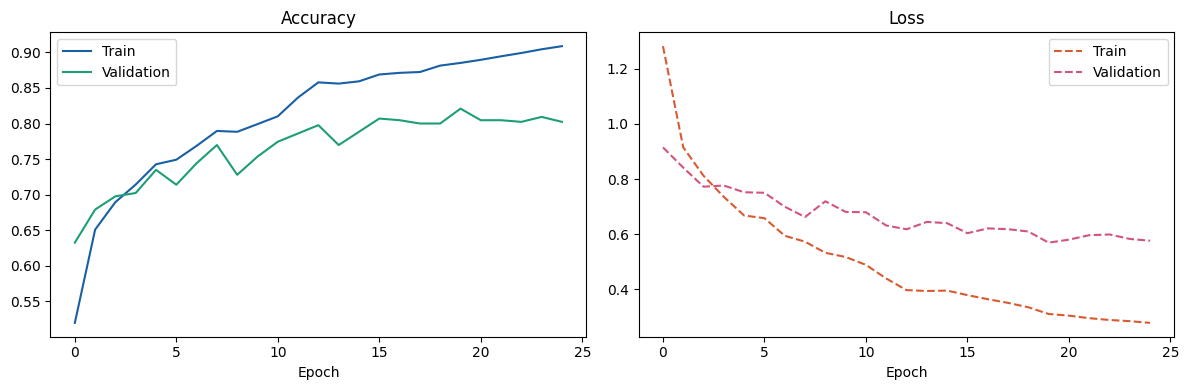

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history1.history['accuracy'], label='Train', color='#185FA5')
ax1.plot(history1.history['val_accuracy'], label='Validation', color='#1D9E75')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history1.history['loss'], label='Train', color='#D85A30', linestyle='--')
ax2.plot(history1.history['val_loss'], label='Validation', color='#D4537E', linestyle='--')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_curves.png', dpi=150)
plt.show()

In [ ]:
model = tf.keras.models.load_model('/content/drive/MyDrive/derma_model_v2.keras')
print("✅ تم تحميل الموديل!")

✅ تم تحميل الموديل!


# 1️⃣3️⃣ التقييم على test set

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

loss, accuracy = model.evaluate(test_data)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy*100:.2f}%")

Found 430 images belonging to 9 classes.
14/14 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step - accuracy: 0.8070 - loss: 0.5646

Test Loss: 0.5646
Test Accuracy: 80.70%


# 1️⃣4️⃣ 2. Classification Report
# 3. Confusion Matrix




In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes
class_names = list(test_data.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

14/14 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step

Classification Report:
              precision    recall  f1-score   support

        acne       0.88      0.90      0.89        50
 blackheades       0.96      0.90      0.93        50
  dark spots       0.90      0.86      0.88        50
         dry       0.59      0.76      0.67        50
      normal       0.75      0.60      0.67        50
        oily       0.68      0.60      0.64        50
       pores       1.00      0.96      0.98        50
  puffy eyes       0.70      0.87      0.78        30
    wrinkles       0.82      0.84      0.83        50

    accuracy                           0.81       430
   macro avg       0.81      0.81      0.81       430
weighted avg       0.81      0.81      0.81       430



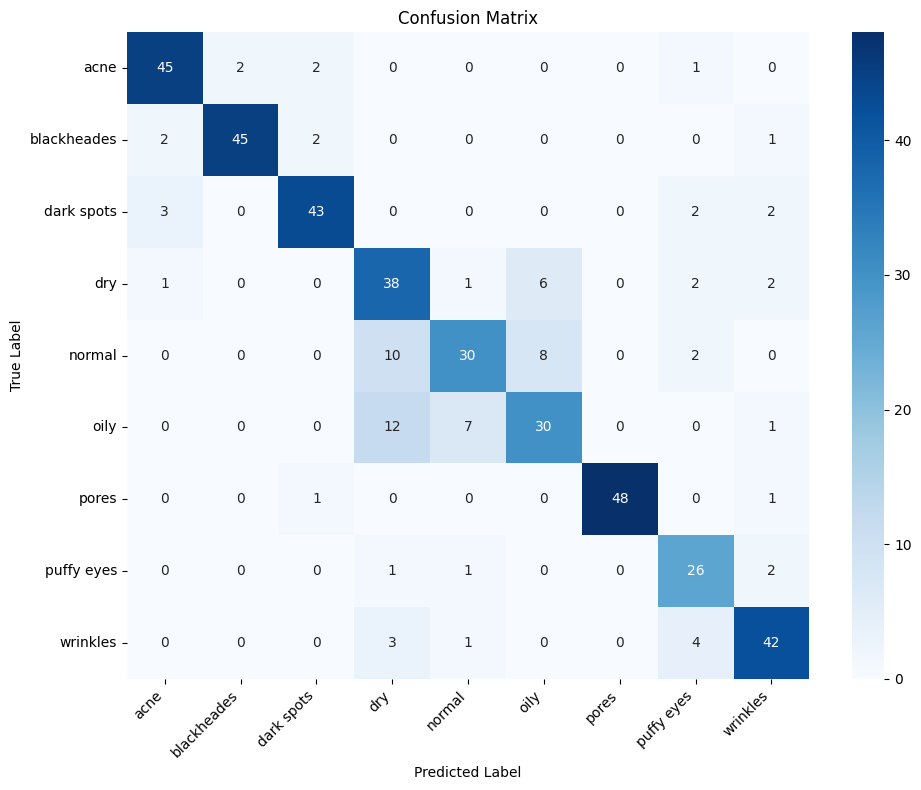

In [ ]:
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
import shutil
from datetime import datetime
from tensorflow.keras.preprocessing import image
import json

PENDING_DIR = "/content/drive/MyDrive/pending_review"
DATASET_DIR = OUTPUT_DIR
os.makedirs(PENDING_DIR, exist_ok=True)

def auto_save_patient_image(img_path, symptoms=""):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array, verbose=0)
    class_names = list(train_data.class_indices.keys())
    predicted_label = class_names[np.argmax(prediction)]
    confidence = float(np.max(prediction))
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    if confidence >= 0.90:
        # ✅ دقة عالية → يضيف للداتاسيت مباشرة
        dest_cls = os.path.join(DATASET_DIR, predicted_label)
        os.makedirs(dest_cls, exist_ok=True)
        shutil.copy(img_path, os.path.join(dest_cls, f"{timestamp}.jpg"))
        print(f"✅ أضيفت للداتاسيت تلقائياً → {predicted_label} ({confidence*100:.1f}%)")
    else:
        # ⏳ دقة منخفضة → تحفظ للمراجعة
        pending_cls = os.path.join(PENDING_DIR, predicted_label)
        os.makedirs(pending_cls, exist_ok=True)
        dest_path = os.path.join(pending_cls, f"{timestamp}.jpg")
        shutil.copy(img_path, dest_path)

        info = {
            "predicted": predicted_label,
            "confidence": round(confidence * 100, 2),
            "symptoms": symptoms,
            "timestamp": timestamp
        }
        with open(dest_path.replace(".jpg", ".json"), "w") as f:
            json.dump(info, f, ensure_ascii=False)

        print(f"⏳ دقة منخفضة ({confidence*100:.1f}%) → محفوظة للمراجعة")

print("✅ جاهز!")

✅ جاهز!


In [ ]:
!pip install gradio

In [ ]:
!pip install fastapi uvicorn nest-asyncio pyngrok -q

In [ ]:
import nest_asyncio
import uvicorn
from fastapi import FastAPI, File, UploadFile
from fastapi.middleware.cors import CORSMiddleware
import numpy as np
from PIL import Image
import io
import threading

nest_asyncio.apply()

app_api = FastAPI()

app_api.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"]
)

arabic_names = {
    "acne": "حب الشباب",
    "blackheades": "الرؤوس السوداء",
    "dark spots": "البقع الداكنة",
    "dry": "البشرة الجافة",
    "normal": "البشرة الطبيعية",
    "oily": "البشرة الدهنية",
    "pores": "المسام الواسعة",
    "puffy eyes": "انتفاخ العيون",
    "wrinkles": "التجاعيد"
}

treatments = {
    "acne": {
        "morning": ["غسول لطيف منظف", "سيروم نياسيناميد 10%", "مرطب خفيف", "واقي شمس SPF50+"],
        "evening": ["غسول لطيف منظف", "بنزويل بيروكسيد 2.5%", "مرطب خفيف"]
    },
    "blackheades": {
        "morning": ["غسول بحمض الساليسيليك", "تونر مقشر خفيف", "مرطب خفيف", "واقي شمس SPF50+"],
        "evening": ["غسول بحمض الساليسيليك", "قناع الطين أسبوعياً", "مرطب خفيف"]
    },
    "dark spots": {
        "morning": ["غسول لطيف", "سيروم فيتامين C", "مرطب", "واقي شمس SPF50+ إلزامي"],
        "evening": ["غسول لطيف", "كريم ريتينول", "مرطب مكثف"]
    },
    "dry": {
        "morning": ["غسول كريمي لطيف", "سيروم هيالورونيك أسيد", "مرطب مكثف", "واقي شمس SPF50+"],
        "evening": ["غسول كريمي لطيف", "زيت وجه مغذي", "مرطب مكثف"]
    },
    "normal": {
        "morning": ["غسول لطيف", "سيروم فيتامين C أو النياسيناميد", "مرطب خفيف", "واقي شمس SPF50+"],
        "evening": ["غسول لطيف", "سيروم مستهدف", "مرطب عادي"]
    },
    "oily": {
        "morning": ["غسول للبشرة الدهنية", "تونر بحمض الساليسيليك", "مرطب خفيف جداً", "واقي شمس مائي SPF50+"],
        "evening": ["غسول للبشرة الدهنية", "سيروم النياسيناميد", "مرطب جل خفيف"]
    },
    "pores": {
        "morning": ["غسول بحمض الساليسيليك", "تونر نياسيناميد", "مرطب خفيف", "واقي شمس SPF50+"],
        "evening": ["غسول عميق", "قناع الطين أسبوعياً", "كريم ريتينول"]
    },
    "puffy eyes": {
        "morning": ["كمادات باردة 5 دقائق", "كريم العين بالكافيين", "واقي شمس SPF50+"],
        "evening": ["كريم العين بالريتينول", "تقليل الملح", "النوم الكافي 8 ساعات"]
    },
    "wrinkles": {
        "morning": ["غسول لطيف", "سيروم فيتامين C", "مرطب مكثف", "واقي شمس SPF50+ إلزامي"],
        "evening": ["غسول لطيف", "كريم ريتينول", "زيت وجه مغذي"]
    }
}

issues_info = {
    "acne": [{"title": "حب الشباب الالتهابي", "desc": "التهاب في الجريبات الشعرية ناتج عن الزيوت والبكتيريا.", "badge": "مزمنة", "type": "red"}],
    "blackheades": [{"title": "انسداد المسام", "desc": "مسام مسدودة بالزيوت والخلايا الجلدية الميتة.", "badge": "مزمنة", "type": "orange"}],
    "dark spots": [{"title": "فرط التصبغ", "desc": "تراكم الميلانين في مناطق معينة من الوجه.", "badge": "مزمنة", "type": "orange"}],
    "dry": [{"title": "جفاف شديد", "desc": "نقص واضح في الرطوبة الطبيعية للبشرة.", "badge": "مزمنة", "type": "red"}],
    "normal": [{"title": "بشرة متوازنة", "desc": "البشرة بحالة جيدة ومتوازنة.", "badge": "متكاملة", "type": "green"}],
    "oily": [{"title": "إفراز مفرط للزيوت", "desc": "الغدد الدهنية تعمل بشكل مفرط.", "badge": "مزمنة", "type": "red"}],
    "pores": [{"title": "مسام واسعة", "desc": "اتساع واضح في المسام نتيجة الدهون الزائدة.", "badge": "مزمنة", "type": "orange"}],
    "puffy eyes": [{"title": "انتفاخ تحت العين", "desc": "احتباس السوائل تحت منطقة العين.", "badge": "مزمنة", "type": "orange"}],
    "wrinkles": [{"title": "تجاعيد وخطوط", "desc": "فقدان الكولاجين والإيلاستين مع التقدم في العمر.", "badge": "مزمنة", "type": "red"}]
}

@app_api.post("/predict")
async def predict(file: UploadFile = File(...)):
    contents = await file.read()
    img = Image.open(io.BytesIO(contents)).convert('RGB').resize((224, 224))
    img_array = np.expand_dims(np.array(img) / 255.0, axis=0)

    prediction = model.predict(img_array, verbose=0)
    class_names = list(train_data.class_indices.keys())
    predicted_label = class_names[np.argmax(prediction)]
    confidence = float(np.max(prediction)) * 100

    # حفظ الصورة بالداتاسيت تلقائياً
    import tempfile, shutil
    from datetime import datetime
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    with tempfile.NamedTemporaryFile(suffix=".jpg", delete=False) as tmp:
        tmp_path = tmp.name
        img.save(tmp_path)

    if confidence >= 90:
        dest_cls = os.path.join(OUTPUT_DIR, predicted_label)
        os.makedirs(dest_cls, exist_ok=True)
        shutil.copy(tmp_path, os.path.join(dest_cls, f"{timestamp}.jpg"))
        print(f"✅ أضيفت للداتاسيت → {predicted_label} ({confidence:.1f}%)")
    else:
        PENDING_DIR = "/content/drive/MyDrive/pending_review"
        pending_cls = os.path.join(PENDING_DIR, predicted_label)
        os.makedirs(pending_cls, exist_ok=True)
        shutil.copy(tmp_path, os.path.join(pending_cls, f"{timestamp}.jpg"))
        print(f"⏳ محفوظة للمراجعة ({confidence:.1f}%)")

    return {
        "label": predicted_label.upper(),
        "arabic": arabic_names.get(predicted_label, predicted_label),
        "confidence": round(confidence, 1),
        "issues": issues_info.get(predicted_label, []),
        "morning": treatments.get(predicted_label, {}).get("morning", []),
        "evening": treatments.get(predicted_label, {}).get("evening", [])
    }

print("✅ FastAPI جاهز!")

✅ FastAPI جاهز!


In [ ]:
import subprocess
import threading
import uvicorn
import nest_asyncio
import os

nest_asyncio.apply()

# أوقفي أي سيرفر قديم
os.system("pkill -f uvicorn")
os.system("pkill -f cloudflared")
os.system("rm -f cloudflared")

import time
time.sleep(2)

# شغّلي السيرفر الجديد
thread = threading.Thread(target=uvicorn.run, kwargs={"app": app_api, "host": "0.0.0.0", "port": 8000})
thread.daemon = True
thread.start()

time.sleep(2)

# Cloudflare Tunnel
import urllib.request
urllib.request.urlretrieve("https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64", "cloudflared")

os.chmod("cloudflared", 0o755)

process = subprocess.Popen(
    ["./cloudflared", "tunnel", "--url", "http://localhost:8000"],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT
)

import re
time.sleep(5)
for _ in range(20):
    line = process.stdout.readline().decode()
    print(line.strip())
    match = re.search(r'https://[a-z0-9\-]+\.trycloudflare\.com', line)
    if match:
        print(f"\n✅ API URL الجديد: {match.group()}")
        break

INFO:     Started server process [49158]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


2026-05-02T22:38:46Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-02T22:38:46Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-02T22:38:47Z INF +--------------------------------------------------------------------------------------------+
2026-05-02T22:38:47Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-02T22:38:47Z INF |  https://speeds-recycling-herbs-man.trycloudflare.com 

In [ ]:
api_url = "https://speeds-recycling-herbs-man.trycloudflare.com"  # ← غيري هاد بالـ URL الجديد

html_content = f"""<!DOCTYPE html>
<html lang="ar" dir="rtl">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Personal Derma Assistant</title>
<link href="https://fonts.googleapis.com/css2?family=Tajawal:wght@400;500;700&display=swap" rel="stylesheet">
<style>
  * {{ margin:0; padding:0; box-sizing:border-box; }}
  body {{ font-family:'Tajawal',sans-serif; background:#F2E6EA; min-height:100vh; display:flex; justify-content:center; }}
  .phone {{ width:100%; max-width:430px; background:#FFF5F7; min-height:100vh; position:relative; }}
  .page {{ display:none; padding:28px 20px; min-height:100vh; }}
  .page.active {{ display:block; }}

  /* الصفحة الرئيسية */
  .home-header {{ text-align:center; margin-bottom:24px; padding-top:20px; }}
  .home-header .app-name {{ font-size:22px; font-weight:700; color:#3D2235; margin-bottom:6px; }}
  .home-header .app-sub {{ font-size:12px; color:#C4829A; }}

  .hero-card {{ background:linear-gradient(135deg,#F9B8C8,#F7CEDB); border-radius:24px; padding:24px 20px; margin-bottom:20px; text-align:center; }}
  .hero-card .ai-badge {{ background:rgba(255,255,255,0.6); color:#9D3F66; font-size:10px; padding:3px 10px; border-radius:10px; display:inline-block; margin-bottom:10px; }}
  .hero-card .hero-icon {{ font-size:36px; margin-bottom:10px; display:block; }}
  .hero-card h3 {{ color:#3D2235; font-size:20px; font-weight:700; margin-bottom:6px; line-height:1.4; }}
  .hero-card p {{ color:#9D3F66; font-size:12px; line-height:1.6; }}

  .upload-btns {{ display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-bottom:20px; }}
  .upload-btn {{ background:#3D2235; color:white; border:none; border-radius:18px; padding:16px 8px; font-size:13px; font-family:'Tajawal',sans-serif; cursor:pointer; display:flex; flex-direction:column; align-items:center; gap:6px; font-weight:500; }}
  .upload-btn.outline {{ background:white; color:#3D2235; border:1.5px solid #F9B8C8; }}
  .upload-btn .icon {{ font-size:22px; }}

  .tips-section {{ background:white; border-radius:20px; padding:16px; }}
  .tips-title {{ font-size:13px; font-weight:700; color:#3D2235; margin-bottom:12px; text-align:center; }}
  .tip-item {{ display:flex; align-items:center; gap:12px; padding:10px 0; border-bottom:0.5px solid #F9E8ED; }}
  .tip-item:last-child {{ border-bottom:none; padding-bottom:0; }}
  .tip-icon {{ width:36px; height:36px; border-radius:50%; display:flex; align-items:center; justify-content:center; font-size:16px; flex-shrink:0; }}
  .tip-text {{ font-size:12px; color:#555; line-height:1.4; }}

  /* صفحة التحميل */
  .loading-page {{ display:flex; flex-direction:column; align-items:center; justify-content:center; min-height:100vh; text-align:center; }}
  .loading-page .icon {{ font-size:60px; margin-bottom:20px; }}
  .loading-page h3 {{ font-size:18px; font-weight:700; color:#3D2235; margin-bottom:8px; }}
  .loading-page p {{ font-size:13px; color:#C4829A; }}

  /* صفحة النتيجة */
  .result-header {{ display:flex; align-items:center; justify-content:space-between; margin-bottom:16px; padding-top:8px; }}
  .back-btn {{ background:white; border:1px solid #F9B8C8; width:36px; height:36px; border-radius:50%; font-size:18px; cursor:pointer; display:flex; align-items:center; justify-content:center; color:#3D2235; flex-shrink:0; }}
  .result-header h3 {{ font-size:16px; font-weight:700; color:#3D2235; font-family:'Tajawal',sans-serif; flex:1; text-align:center; }}

  .img-preview {{ width:100%; height:200px; object-fit:cover; border-radius:20px; margin-bottom:12px; display:none; }}

  .result-info {{ text-align:center; margin-bottom:16px; }}
  .label-badge {{ display:inline-block; background:#3D2235; color:white; font-size:11px; padding:4px 14px; border-radius:10px; margin-bottom:6px; }}
  .confidence-text {{ font-size:12px; color:#C4829A; margin-bottom:6px; }}
  .result-desc {{ font-size:12px; color:#666; line-height:1.6; }}

  .metrics {{ display:flex; gap:10px; margin-bottom:16px; }}
  .metric {{ flex:1; background:white; border-radius:14px; padding:10px 8px; text-align:center; }}
  .metric-label {{ font-size:10px; color:#888; margin-bottom:6px; }}
  .metric-bar-wrap {{ background:#F5E8EC; border-radius:4px; height:4px; margin-bottom:6px; overflow:hidden; }}
  .metric-bar {{ height:4px; border-radius:4px; }}
  .metric-val {{ font-size:10px; font-weight:700; }}

  .section-title {{ font-size:13px; font-weight:700; color:#3D2235; margin-bottom:10px; }}
  .issue-card {{ background:white; border-radius:14px; padding:12px 14px; margin-bottom:8px; }}
  .issue-title {{ font-size:12px; font-weight:700; color:#3D2235; margin-bottom:4px; }}
  .issue-desc {{ font-size:11px; color:#888; line-height:1.5; }}
  .badge {{ font-size:10px; padding:2px 10px; border-radius:8px; display:inline-block; margin-bottom:6px; font-weight:500; }}
  .badge.red {{ background:#FADBD8; color:#C0392B; }}
  .badge.orange {{ background:#FDEBD0; color:#E67E22; }}
  .badge.green {{ background:#D5F5E3; color:#27AE60; }}

  .primary-btn {{ width:100%; background:linear-gradient(135deg,#E07A8A,#C05070); color:white; border:none; border-radius:18px; padding:14px; font-size:14px; font-family:'Tajawal',sans-serif; cursor:pointer; font-weight:700; margin-top:14px; }}

  /* صفحة الروتين */
  .routine-header {{ display:flex; align-items:center; gap:10px; margin-bottom:12px; margin-top:16px; }}
  .routine-header h4 {{ font-size:14px; font-weight:700; color:#3D2235; font-family:'Tajawal',sans-serif; }}
  .routine-step {{ background:white; border-radius:14px; padding:12px 14px; margin-bottom:8px; display:flex; align-items:center; gap:12px; }}
  .step-num {{ width:26px; height:26px; background:#F9B8C8; color:#9D3F66; border-radius:50%; display:flex; align-items:center; justify-content:center; font-size:11px; font-weight:700; flex-shrink:0; }}
  .step-text {{ font-size:12px; color:#3D2235; line-height:1.4; }}

  .disclaimer-box {{ background:#FFF3CD; border-radius:14px; padding:12px 14px; font-size:11px; color:#856404; line-height:1.6; margin-top:16px; text-align:center; }}

  input[type=file] {{ display:none; }}
</style>
</head>
<body>
<div class="phone">

  <!-- الصفحة الرئيسية -->
  <div class="page active" id="page-home">
    <div class="home-header">
      <div class="app-name">🌸 Personal Derma Assistant</div>
      <div class="app-sub">مساعدك الشخصي لتشخيص مشاكل البشرة</div>
    </div>

    <div class="hero-card">
      <div class="ai-badge">✨ AI</div>
      <span class="hero-icon">🔬</span>
      <h3>صوّري بشرتك<br>واحصلي على تحليل ذكي</h3>
      <p>تحليل سريع لمشاكل البشرة الشائعة<br>مع توصيات وروتين يومي مخصص لك</p>
    </div>

    <div class="upload-btns">
      <label for="camera-input" class="upload-btn">
        <span class="icon">📷</span>
        التقاط صورة
      </label>
      <label for="gallery-input" class="upload-btn outline">
        <span class="icon">🖼️</span>
        من المعرض
      </label>
    </div>
    <input type="file" id="camera-input" accept="image/*" capture="user" onchange="handleImage(event)">
    <input type="file" id="gallery-input" accept="image/*" onchange="handleImage(event)">

    <div class="tips-section">
      <div class="tips-title">💡 نصائح لصورة دقيقة</div>
      <div class="tip-item">
        <div class="tip-icon" style="background:#FDEBD0;">☀️</div>
        <div class="tip-text">استخدمي إضاءة طبيعية وتجنّبي الفلاش</div>
      </div>
      <div class="tip-item">
        <div class="tip-icon" style="background:#F9B8C8;">🌸</div>
        <div class="tip-text">صوّري الوجه بدون مكياج وبعد غسل البشرة</div>
      </div>
      <div class="tip-item">
        <div class="tip-icon" style="background:#D6EAF8;">🔍</div>
        <div class="tip-text">اقتربي من الكاميرا لإظهار تفاصيل البشرة بوضوح</div>
      </div>
    </div>
  </div>

  <!-- صفحة التحميل -->
  <div class="page" id="page-loading">
    <div class="loading-page">
      <div class="icon">🔬</div>
      <h3>جاري تحليل البشرة...</h3>
      <p>يرجى الانتظار لحظة</p>
    </div>
  </div>

  <!-- صفحة النتيجة -->
  <div class="page" id="page-result">
    <div class="result-header">
      <button class="back-btn" onclick="goTo('page-home')">‹</button>
      <h3>نتيجة التحليل</h3>
      <div style="width:36px;"></div>
    </div>

    <img id="preview-img" class="img-preview" src="" alt="صورة البشرة">

    <div class="result-info">
      <div id="label-badge" class="label-badge"></div>
      <div id="confidence-text" class="confidence-text"></div>
      <div id="result-desc" class="result-desc"></div>
    </div>

    <div class="metrics">
      <div class="metric">
        <div class="metric-label">الترطيب</div>
        <div class="metric-bar-wrap"><div class="metric-bar" id="bar-moisture"></div></div>
        <div class="metric-val" id="val-moisture"></div>
      </div>
      <div class="metric">
        <div class="metric-label">الدهون</div>
        <div class="metric-bar-wrap"><div class="metric-bar" id="bar-oil"></div></div>
        <div class="metric-val" id="val-oil"></div>
      </div>
      <div class="metric">
        <div class="metric-label">الحساسية</div>
        <div class="metric-bar-wrap"><div class="metric-bar" id="bar-sens"></div></div>
        <div class="metric-val" id="val-sens"></div>
      </div>
    </div>

    <div class="section-title">مشاكل ظاهرة</div>
    <div id="issues-container"></div>
    <button class="primary-btn" onclick="goTo('page-routine')">💊 عرض التوصيات والروتين</button>
  </div>

  <!-- صفحة الروتين -->
  <div class="page" id="page-routine">
    <div class="result-header">
      <button class="back-btn" onclick="goTo('page-result')">‹</button>
      <h3>الروتين المقترح</h3>
      <div style="width:36px;"></div>
    </div>

    <div class="routine-header">
      <span style="font-size:20px;">☀️</span>
      <h4>صباحاً</h4>
    </div>
    <div id="morning-steps"></div>

    <div class="routine-header">
      <span style="font-size:20px;">🌙</span>
      <h4>مساءً</h4>
    </div>
    <div id="evening-steps"></div>

    <div class="disclaimer-box">
      ⚠️ هذا التقييم للأغراض التعليمية فقط.<br>
      راجع طبيب جلدية متخصص للتشخيص الدقيق.
    </div>
  </div>

</div>

<script>
const API_URL = "{api_url}";

const metrics = {{
  acne: {{ moisture:{{val:"منخفض",color:"#E74C3C",pct:"30%"}}, oil:{{val:"مرتفع",color:"#E67E22",pct:"80%"}}, sens:{{val:"متوسط",color:"#F1C40F",pct:"50%"}} }},
  blackheades: {{ moisture:{{val:"طبيعي",color:"#27AE60",pct:"55%"}}, oil:{{val:"مرتفع",color:"#E67E22",pct:"75%"}}, sens:{{val:"منخفض",color:"#27AE60",pct:"25%"}} }},
  "dark spots": {{ moisture:{{val:"طبيعي",color:"#27AE60",pct:"60%"}}, oil:{{val:"طبيعي",color:"#27AE60",pct:"50%"}}, sens:{{val:"متوسط",color:"#F1C40F",pct:"40%"}} }},
  dry: {{ moisture:{{val:"منخفض جداً",color:"#E74C3C",pct:"15%"}}, oil:{{val:"منخفض",color:"#3498DB",pct:"20%"}}, sens:{{val:"مرتفع",color:"#E74C3C",pct:"70%"}} }},
  normal: {{ moisture:{{val:"طبيعي",color:"#27AE60",pct:"65%"}}, oil:{{val:"طبيعي",color:"#27AE60",pct:"45%"}}, sens:{{val:"منخفض",color:"#27AE60",pct:"25%"}} }},
  oily: {{ moisture:{{val:"طبيعي",color:"#27AE60",pct:"60%"}}, oil:{{val:"مرتفع جداً",color:"#E74C3C",pct:"90%"}}, sens:{{val:"متوسط",color:"#F1C40F",pct:"40%"}} }},
  pores: {{ moisture:{{val:"طبيعي",color:"#27AE60",pct:"55%"}}, oil:{{val:"مرتفع",color:"#E67E22",pct:"70%"}}, sens:{{val:"منخفض",color:"#27AE60",pct:"30%"}} }},
  "puffy eyes": {{ moisture:{{val:"طبيعي",color:"#27AE60",pct:"60%"}}, oil:{{val:"طبيعي",color:"#27AE60",pct:"45%"}}, sens:{{val:"متوسط",color:"#F1C40F",pct:"45%"}} }},
  wrinkles: {{ moisture:{{val:"منخفض",color:"#E74C3C",pct:"35%"}}, oil:{{val:"منخفض",color:"#3498DB",pct:"25%"}}, sens:{{val:"متوسط",color:"#F1C40F",pct:"45%"}} }}
}};

const descs = {{
  ACNE: "تبدو البشرة تعاني من حب الشباب الناتج عن انسداد المسام والبكتيريا.",
  BLACKHEADES: "تظهر رؤوس سوداء ناتجة عن انسداد المسام بالزيوت والخلايا الميتة.",
  "DARK SPOTS": "تظهر بقع داكنة وتفاوت في لون البشرة ناتج عن تراكم الميلانين.",
  DRY: "البشرة تعاني من جفاف واضح ونقص في الرطوبة الطبيعية.",
  NORMAL: "تبدو البشرة بصحة جيدة بشكل عام مع توازن في الترطيب والزيوت.",
  OILY: "البشرة تعاني من إفراز مفرط للزيوت مما يؤدي للمسام الواسعة.",
  PORES: "تظهر مسام واسعة نتيجة الدهون الزائدة وضعف مرونة الجلد.",
  "PUFFY EYES": "يظهر انتفاخ تحت العين ناتج عن احتباس السوائل.",
  WRINKLES: "تظهر علامات التقدم في العمر مع وجود خطوط وتجاعيد واضحة."
}};

function goTo(pageId) {{
  document.querySelectorAll('.page').forEach(p => p.classList.remove('active'));
  document.getElementById(pageId).classList.add('active');
  window.scrollTo(0,0);
}}

async function handleImage(event) {{
  const file = event.target.files[0];
  if (!file) return;

  const reader = new FileReader();
  reader.onload = e => {{
    const img = document.getElementById('preview-img');
    img.src = e.target.result;
    img.style.display = 'block';
  }};
  reader.readAsDataURL(file);

  goTo('page-loading');

  try {{
    const formData = new FormData();
    formData.append('file', file);
    const response = await fetch(API_URL + '/predict', {{ method:'POST', body:formData }});
    const result = await response.json();
    showResult(result);
  }} catch(err) {{
    alert('خطأ في الاتصال: ' + err.message);
    goTo('page-home');
  }}
}}

function showResult(result) {{
  const key = result.label.toLowerCase();
  const m = metrics[key] || metrics['normal'];

  document.getElementById('label-badge').textContent = result.label;
  document.getElementById('confidence-text').textContent = `📊 دقة التشخيص: ${{result.confidence}}% — ${{result.arabic}}`;
  document.getElementById('result-desc').textContent = descs[result.label] || '';

  setMetric('moisture', m.moisture);
  setMetric('oil', m.oil);
  setMetric('sens', m.sens);

  const container = document.getElementById('issues-container');
  container.innerHTML = '';
  result.issues.forEach(issue => {{
    container.innerHTML += `
      <div class="issue-card">
        <span class="badge ${{issue.type}}">${{issue.badge}}</span>
        <div class="issue-title">${{issue.title}}</div>
        <div class="issue-desc">${{issue.desc}}</div>
      </div>`;
  }});

  const morning = document.getElementById('morning-steps');
  const evening = document.getElementById('evening-steps');
  morning.innerHTML = '';
  evening.innerHTML = '';

  result.morning.forEach((step, i) => {{
    morning.innerHTML += `<div class="routine-step"><div class="step-num">${{i+1}}</div><div class="step-text">${{step}}</div></div>`;
  }});
  result.evening.forEach((step, i) => {{
    evening.innerHTML += `<div class="routine-step"><div class="step-num">${{i+1}}</div><div class="step-text">${{step}}</div></div>`;
  }});

  goTo('page-result');
}}

function setMetric(type, data) {{
  document.getElementById(`bar-${{type}}`).style.cssText = `background:${{data.color}};width:${{data.pct}};height:4px;border-radius:4px;`;
  const val = document.getElementById(`val-${{type}}`);
  val.textContent = data.val;
  val.style.color = data.color;
}}
</script>
</body>
</html>"""

from IPython.display import HTML
with open('app_final.html', 'w', encoding='utf-8') as f:
    f.write(html_content)
HTML(html_content)